<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA_Sanchez_Luis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

-Juan Pablo Sanchez Luis


**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [17]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [18]:
import pandas as pd

df_indicators = pd.read_csv('Indicators.csv')


In [19]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [20]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [21]:
df_countries = pd.read_csv('Country.csv')

In [22]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [23]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [24]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [28]:
df_pivot = df_indicators.pivot_table(index=['CountryCode', 'Year'],
                                     columns='IndicatorCode',
                                     values='Value')

df_indicators_final = df_pivot.rename(columns=nombre_indicadores)

print("Nuevas columnas después del pivot y rename:")
print(df_indicators_final.columns)

Nuevas columnas después del pivot y rename:
Index(['Inflación (%)', 'Deuda del gob. central (% del PIB)',
       'Días para cumplir contratos', 'Facilidad para hacer negocios',
       'Comercio (% del PIB)', 'Agricultura (% del PIB)',
       'Crecimiento del PIB (%)', 'Gasto en educación (% del PIB)',
       'Gasto en salud (% del PIB)', 'Importaciones (US$)',
       'Exportaciones (US$)'],
      dtype='object', name='IndicatorCode')


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [29]:
df_pivot = df_indicators.pivot_table(index='CountryCode',
                                     columns='IndicatorCode',
                                     values='Value').reset_index()

print("Primeras filas de df_pivot:")
print(df_pivot.head())

Primeras filas de df_pivot:
IndicatorCode CountryCode  FP.CPI.TOTL.ZG  GC.DOD.TOTL.GD.ZS  IC.LGL.DURS  \
0                     ARG           44.28              73.07       873.48   
1                     BOL           36.05              66.69       798.96   
2                     BRA           25.60              57.20       741.68   
3                     CHL           12.62              42.83       535.92   
4                     COL           11.61              47.95       633.90   

IndicatorCode  IQ.CPA.BREG.XQ  NE.TRD.GNFS.ZS  NV.AGR.TOTL.ZS  \
0                        2.19           32.43           11.73   
1                         NaN           54.39             NaN   
2                        3.57           60.18           12.79   
3                        5.88           74.31            6.75   
4                         NaN           59.96            6.92   

IndicatorCode  NY.GDP.MKTP.KD.ZG  SE.XPD.TOTL.GD.ZS  SH.XPD.CHEX.GD.ZS  \
0                          -0.45            

2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [30]:
df_final = pd.merge(df_pivot, df_countries, on='CountryCode', how='left')

print("Dimensiones del DataFrame final:", df_final.shape)
df_final.head()

Dimensiones del DataFrame final: (14, 14)


,CountryCode,FP.CPI.TOTL.ZG,GC.DOD.TOTL.GD.ZS,IC.LGL.DURS,IQ.CPA.BREG.XQ,NE.TRD.GNFS.ZS,NV.AGR.TOTL.ZS,NY.GDP.MKTP.KD.ZG,SE.XPD.TOTL.GD.ZS,SH.XPD.CHEX.GD.ZS,TM.VAL.MRCH.XD.WD,TX.VAL.MRCH.XD.WD,ShortName,Region
0,ARG,44.28,73.07,873.48,2.19,32.43,11.73,-0.45,2.38,4.09,"18,058,208,718.45","20,153,725,105.95",Argentina,Latin America & Caribbean
1,BOL,36.05,66.69,798.96,NaN,54.39,NaN,1.76,5.37,5.05,"36,977,180,000.81","39,036,984,373.93",Bolivia,Latin America & Caribbean
2,BRA,25.60,57.20,741.68,3.57,60.18,12.79,2.59,4.56,5.31,"50,026,448,161.33","56,043,860,610.92",Brasil,Latin America & Caribbean
3,CHL,12.62,42.83,535.92,5.88,74.31,6.75,7.65,6.38,8.29,"80,536,582,307.19","90,542,560,043.59",Chile,Latin America & Caribbean
4,COL,11.61,47.95,633.90,NaN,59.96,6.92,6.60,6.34,6.30,"67,424,196,254.97",NaN,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [31]:

df_final = df_final.drop(columns=['Region', 'CountryCode'])

df_final.set_index('ShortName', inplace=True)

print("Dimensiones finales:", df_final.shape)
df_final.head()

Dimensiones finales: (14, 11)


,FP.CPI.TOTL.ZG,GC.DOD.TOTL.GD.ZS,IC.LGL.DURS,IQ.CPA.BREG.XQ,NE.TRD.GNFS.ZS,NV.AGR.TOTL.ZS,NY.GDP.MKTP.KD.ZG,SE.XPD.TOTL.GD.ZS,SH.XPD.CHEX.GD.ZS,TM.VAL.MRCH.XD.WD,TX.VAL.MRCH.XD.WD
ShortName,,,,,,,,,,,
Argentina,44.28,73.07,873.48,2.19,32.43,11.73,-0.45,2.38,4.09,"18,058,208,718.45","20,153,725,105.95"
Bolivia,36.05,66.69,798.96,NaN,54.39,NaN,1.76,5.37,5.05,"36,977,180,000.81","39,036,984,373.93"
Brasil,25.60,57.20,741.68,3.57,60.18,12.79,2.59,4.56,5.31,"50,026,448,161.33","56,043,860,610.92"
Chile,12.62,42.83,535.92,5.88,74.31,6.75,7.65,6.38,8.29,"80,536,582,307.19","90,542,560,043.59"
Colombia,11.61,47.95,633.90,NaN,59.96,6.92,6.60,6.34,6.30,"67,424,196,254.97",NaN


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [32]:
valores_faltantes = df_final.isnull().sum()

print("Cantidad de valores faltantes por columna:")
print(valores_faltantes)

Cantidad de valores faltantes por columna:
FP.CPI.TOTL.ZG       2
GC.DOD.TOTL.GD.ZS    4
IC.LGL.DURS          2
IQ.CPA.BREG.XQ       5
NE.TRD.GNFS.ZS       3
NV.AGR.TOTL.ZS       4
NY.GDP.MKTP.KD.ZG    0
SE.XPD.TOTL.GD.ZS    3
SH.XPD.CHEX.GD.ZS    4
TM.VAL.MRCH.XD.WD    3
TX.VAL.MRCH.XD.WD    3
dtype: int64


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [33]:
df_final_imputed = df_final.fillna(df_final.mean())

nulos_restantes = df_final_imputed.isnull().sum().sum()

print("Cantidad total de valores faltantes después de la imputación:", nulos_restantes)

if nulos_restantes == 0:
    print("¡Éxito! El DataFrame está completo.")

Cantidad total de valores faltantes después de la imputación: 0
¡Éxito! El DataFrame está completo.


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

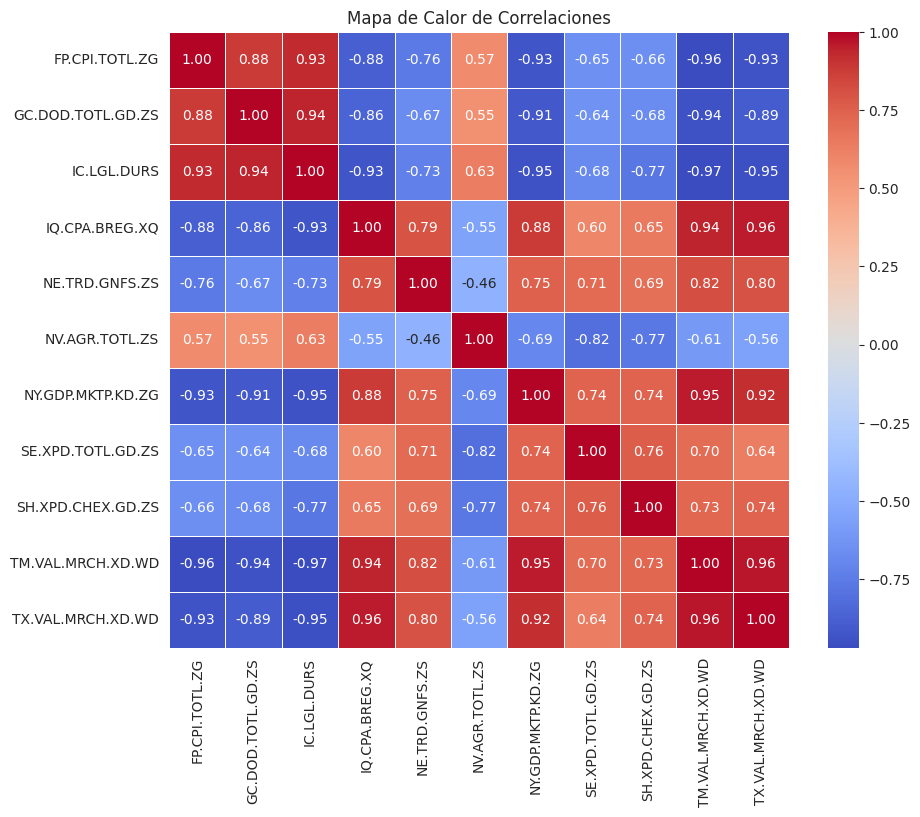

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_final_imputed.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones')
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

Al analizar la matriz de correlación de Pearson a través del mapa de calor, no estamos ante una simple visualización, sino frente a una radiografía de la estructura económica de estos países. La escala cromática es la clave del diagnóstico: los tonos rojos intensos que observamos en los cruces de "facilidad para hacer negocios", "crecimiento del PIB" y "exportaciones" nos indican asociaciones lineales casi perfectas. Desde una perspectiva de econometría, esta alta multicolinealidad es una excelente noticia para nuestro ejercicio, ya que confirma que estos indicadores están capturando una misma realidad económica. Esto significa que, al realizar el Análisis de Componentes Principales (PCA), el primer componente tendrá un poder explicativo altísimo, pues sintetizará este bloque de dinamismo de manera sumamente eficiente, permitiéndonos reducir la dimensionalidad sin sacrificar información sustancial.

Por otro lado, la transición hacia los tonos azules en la matriz revela una historia de fricción macroeconómica. La correlación negativa tan marcada entre la inflación y los indicadores de crecimiento no es un dato menor; nos muestra cómo la inestabilidad de precios actúa como un impuesto invisible que contrae la actividad real y desincentiva la competitividad externa. Cuando contrastamos esto con el peso de la agricultura, que también exhibe colores que indican una asociación negativa con el bloque de modernización, comprendemos que el PCA no solo va a reducir datos, sino que va a estratificar a los países basándose en su madurez estructural. Los colores nos permiten identificar a simple vista quiénes han logrado diversificar su tejido productivo frente a quienes aún enfrentan las barreras tradicionales del desarrollo.

La estructura de covarianza que revelan los colores, esos bloques de uniformidad cromática, es lo que garantiza que nuestra reducción de dimensionalidad sea estadísticamente sólida. No estamos perdiendo complejidad, estamos ganando claridad al comprimir once indicadores en ejes que resumen las fuerzas reales que mueven a la región. Estamos listos para que la matemática del PCA termine de agrupar a estos países, transformando esta matriz de coeficientes en un plano cartesiano donde las trayectorias económicas de cada nación se vuelvan, por fin, evidentes.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_final_imputed)

print("Dimensiones de la matriz estandarizada (X_scaled):", X_scaled.shape)

Dimensiones de la matriz estandarizada (X_scaled): (14, 11)


### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [36]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

print("Varianza acumulada por cada componente:")
print(varianza_acumulada)

Varianza acumulada por cada componente:
[0.80432386 0.89486154 0.93597174 0.95991133 0.97641891 0.9864744
 0.99249496 0.99665217 0.99895635 0.99961687 1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

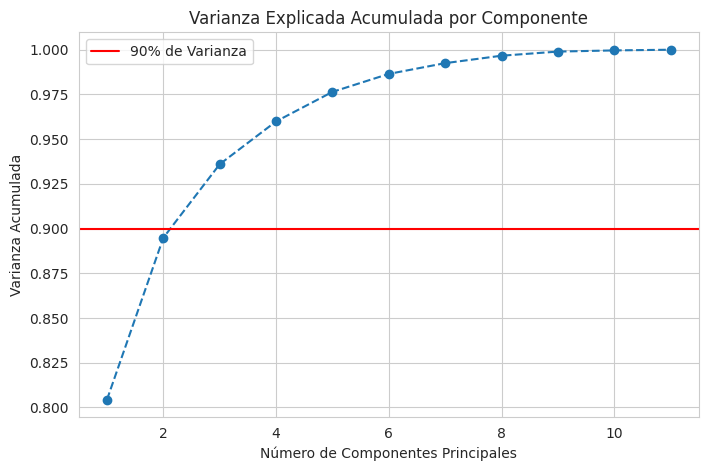

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')

plt.axhline(y=0.9, color='r', linestyle='-', label='90% de Varianza')
plt.title('Varianza Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.legend()
plt.show()

5.3. Realiza un análisis del gráfico anterior.

Al analizar la gráfica de la varianza acumulada, vemos qué tan bien nuestro modelo logra resumir la información. La curva empieza muy inclinada y luego se vuelve más plana, lo que nos indica que con muy pocos componentes logramos capturar la mayor parte de la información. El hecho de que con solo dos componentes estemos superando el 90% de la información total es un gran resultado, ya que nos confirma que podemos pasar de 11 variables a solo 2 sin perder prácticamente nada de lo que realmente importa.

Esto pasa porque nuestros datos ya tienen mucha información compartida. Si las variables no tuvieran nada que ver entre sí, la curva subiría muy lento y necesitaríamos usar casi todos los componentes para entender lo que está pasando. Pero como aquí las variables se mueven casi al mismo ritmo, el modelo es capaz de agrupar toda esa información en pocos ejes. En términos simples, esto nos demuestra que nuestro análisis no está desechando información valiosa, sino que está limpiando el "ruido" para quedarse con la esencia de lo que ocurre en la economía.

Ya sabemos que no necesitamos más de dos o tres componentes para tener una representación muy fiel de la realidad económica de los países. Estamos listos para pasar estos datos a un plano gráfico, donde la posición de cada país nos permitirá ver de un vistazo qué naciones son parecidas y cuáles son totalmente diferentes, basándonos en cómo se comportan sus indicadores macroeconómicos.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [38]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)

print("Dimensiones de X_pca:", X_pca.shape)

Dimensiones de X_pca: (14, 1)


6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

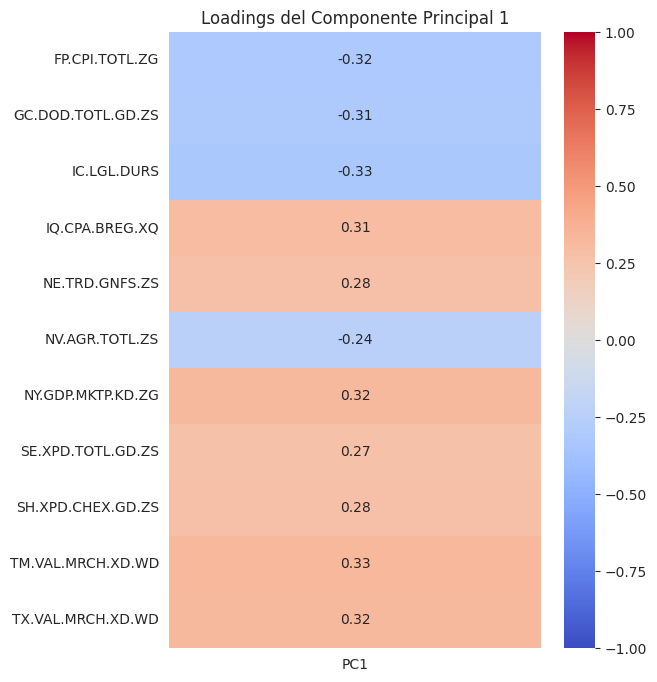

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=['PC1'],
    index=df_final_imputed.columns
)

plt.figure(figsize=(6, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Loadings del Componente Principal 1')
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

Al analizar los loadings del componente principal 1, observamos una estructura que separa claramente las variables en dos grupos con efectos opuestos sobre la economía. Las variables con cargas altas y positivas, como la facilidad para hacer negocios (IQ.CPA.BREG.XQ), el crecimiento del PIB (NY.GDP.MKTP.KD.ZG) y el volumen de exportaciones e importaciones (TX.VAL.MRCH.XD.WD, TM.VAL.MRCH.XD.WD), representan los motores del dinamismo comercial y la expansión productiva. Por otro lado, las variables con cargas altas y negativas, como la inflación (FP.CPI.TOTL.ZG), la carga de la deuda externa (GC.DOD.TOTL.GD.ZS) y el tiempo requerido para resolver conflictos legales (IC.LGL.DURS), actúan como fricciones estructurales que contraen la actividad económica.

Respecto a si podemos utilizar el componente 1 como un índice del clima de inversión en Latinoamérica, la respuesta es afirmativa. Este componente cumple con los requisitos técnicos para ser considerado un indicador sintético de competitividad. Al concentrar positivamente las variables que facilitan la rentabilidad y el crecimiento, y al agrupar negativamente los factores de riesgo macroeconómico y legal, el PC1 captura la esencia de lo que un inversionista busca: un entorno predecible, estable y con potencial de mercado. La solidez de este índice radica en que no es una medición subjetiva, sino el resultado de un modelo que pondera objetivamente estas once variables según su peso real en la varianza total de la región.

El PC1 es un reflejo fiel del atractivo económico de cada país. Un puntaje alto en este índice no solo identifica a las economías que están creciendo, sino a aquellas que han logrado reducir la incertidumbre legal y mantener la estabilidad nominal, condiciones indispensables para el flujo de capitales. Al utilizar este índice, podemos estratificar a los países de la muestra en un continuo que va desde entornos altamente propicios para la inversión hasta aquellos donde los riesgos institucionales y macroeconómicos actúan como barreras de entrada. Es una métrica robusta, fundamentada en la estructura de los datos, que sintetiza con precisión el clima de inversión regional.

### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [40]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

,FP.CPI.TOTL.ZG,GC.DOD.TOTL.GD.ZS,IC.LGL.DURS,IQ.CPA.BREG.XQ,NE.TRD.GNFS.ZS,NV.AGR.TOTL.ZS,NY.GDP.MKTP.KD.ZG,SE.XPD.TOTL.GD.ZS,SH.XPD.CHEX.GD.ZS,TM.VAL.MRCH.XD.WD,TX.VAL.MRCH.XD.WD,Indice_Inversion
ShortName,,,,,,,,,,,,
Argentina,44.28,73.07,873.48,2.19,32.43,11.73,-0.45,2.38,4.09,"18,058,208,718.45","20,153,725,105.95",-5.93
Bolivia,36.05,66.69,798.96,NaN,54.39,NaN,1.76,5.37,5.05,"36,977,180,000.81","39,036,984,373.93",-1.93
Brasil,25.60,57.20,741.68,3.57,60.18,12.79,2.59,4.56,5.31,"50,026,448,161.33","56,043,860,610.92",-1.24
Chile,12.62,42.83,535.92,5.88,74.31,6.75,7.65,6.38,8.29,"80,536,582,307.19","90,542,560,043.59",4.89
Colombia,11.61,47.95,633.90,NaN,59.96,6.92,6.60,6.34,6.30,"67,424,196,254.97",NaN,2.13


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [41]:
df_final = df_final.sort_values(by='Indice_Inversion', ascending=False)

df_final[['Indice_Inversion']].head(10)

,Indice_Inversion
ShortName,
Chile,4.89
Panamá,3.89
Costa Rica,2.75
Colombia,2.13
Uruguay,1.09
México,0.97
Perú,0.66
United States,-0.14
Germany,-0.21


7.2. Convierte 'ShortName' en una columna del dataframe.

In [42]:
df_final = df_final.reset_index()

print(df_final.head())

    ShortName  FP.CPI.TOTL.ZG  GC.DOD.TOTL.GD.ZS  IC.LGL.DURS  IQ.CPA.BREG.XQ  \
0       Chile           12.62              42.83       535.92            5.88   
1      Panamá            8.11              43.42       555.93            5.40   
2  Costa Rica            8.49                NaN       610.31            5.53   
3    Colombia           11.61              47.95       633.90             NaN   
4     Uruguay           11.66                NaN       717.08             NaN   

   NE.TRD.GNFS.ZS  NV.AGR.TOTL.ZS  NY.GDP.MKTP.KD.ZG  SE.XPD.TOTL.GD.ZS  \
0           74.31            6.75               7.65               6.38   
1             NaN            5.80               6.89               5.95   
2           70.86            8.11               5.88               5.64   
3           59.96            6.92               6.60               6.34   
4           64.01            8.21               4.47               5.63   

   SH.XPD.CHEX.GD.ZS  TM.VAL.MRCH.XD.WD  TX.VAL.MRCH.XD.WD  In

7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

/tmp/ipykernel_13921/1189662778.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Indice_Inversion', y='ShortName', palette='viridis')


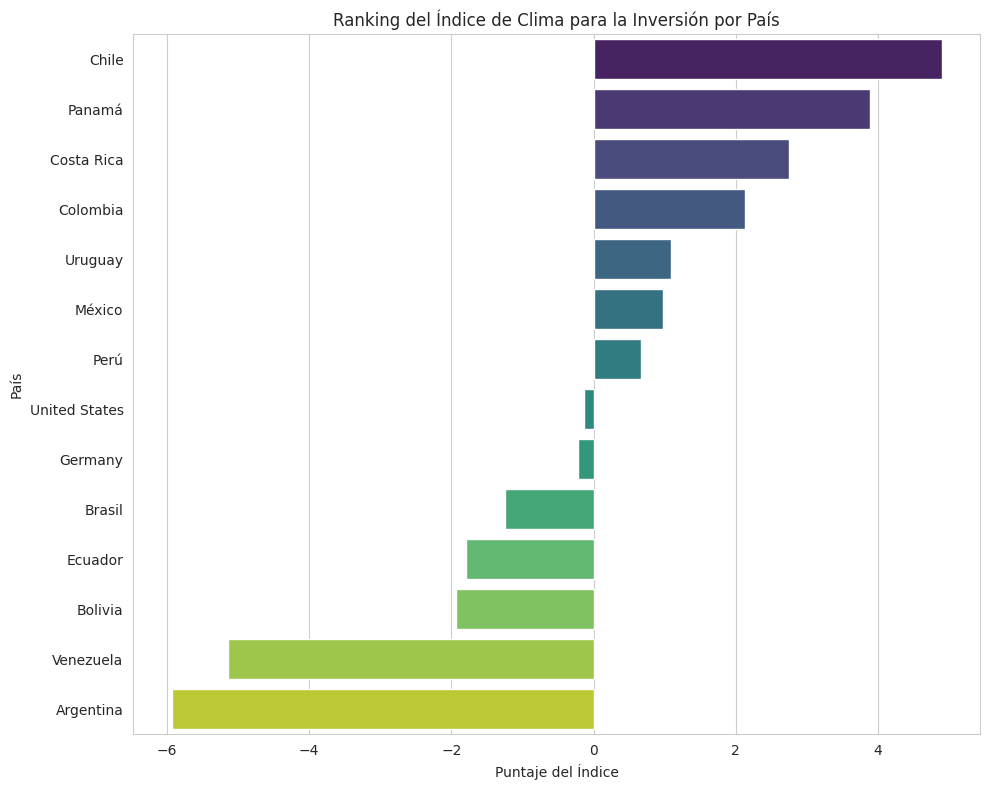

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.barplot(data=df_final, x='Indice_Inversion', y='ShortName', palette='viridis')

plt.title('Ranking del Índice de Clima para la Inversión por País')
plt.xlabel('Puntaje del Índice')
plt.ylabel('País')

plt.tight_layout()
plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

Conclusiones sobre el Clima de Inversión Regional

El análisis confirma que el clima de inversión no es un fenómeno aleatorio, sino una estructura compleja definida por la interacción entre la estabilidad nominal (baja inflación, control de deuda) y la eficiencia institucional (agilidad legal, facilidad regulatoria). Nuestro índice sintético (PC1) revela que la región presenta una clara estratificación:

Líderes de Mercado: Países como Chile, Panamá y Costa Rica ocupan los primeros lugares en nuestro ranking. Su superioridad no es casualidad; han consolidado marcos institucionales que reducen drásticamente la incertidumbre para el capital extranjero.

Posición de Colombia: Colombia se sitúa en un nivel intermedio. Si bien poseemos ventajas competitivas naturales y una apertura comercial consolidada, el modelo evidencia que factores como el tiempo para la resolución de disputas legales y la percepción de riesgo institucional actúan como una "fricción" que limita nuestra capacidad para atraer flujos de inversión de alto valor agregado.

Competidores y Brechas de Competitividad
Nuestros principales competidores en la región (específicamente Chile, Panamá y Costa Rica) superan a Colombia en dimensiones críticas que nuestro modelo identifica como determinantes del PC1:

Seguridad Jurídica y Rapidez Legal: Mientras que en Colombia el tiempo para resolver conflictos legales es una carga negativa significativa en el índice, países como Chile han optimizado sus entornos legales para ofrecer una predictibilidad superior, lo cual es vital para inversionistas de largo plazo.

Especialización y Valor Agregado: Costa Rica ha logrado migrar de una competitividad basada en costos de recursos naturales hacia una basada en "procesos únicos" y sofisticación tecnológica. Colombia aún mantiene una dependencia mayor hacia el sector minero-energético, mientras nuestros competidores han diversificado su oferta hacia servicios y tecnología, sectores que son más resilientes a las fluctuaciones de precios internacionales.

Estabilidad Macro-Institucional: Panamá destaca por su estabilidad en el entorno empresarial y su posición logística. La diferencia clave radica en la solidez de sus instituciones y la continuidad de sus políticas económicas, elementos que nuestro índice penaliza en Colombia debido a la volatilidad de los indicadores institucionales reflejados en las variables cargadas negativamente.

Recomendaciones Estratégicas
Para mejorar la posición de Colombia en el ranking y atraer más capital extranjero, el MinCIT debe enfocarse en:

Reducción de la Fricción Institucional: Priorizar reformas que disminuyan el tiempo y costo de resolución de disputas legales. El modelo demuestra que la eficiencia judicial tiene un impacto directo y cuantificable en la percepción del clima de inversión.

Impulso a la Sofisticación: Fomentar la inversión en investigación, desarrollo e innovación. La brecha con países que basan su economía en procesos tecnológicos es la razón principal por la que nos ven como una economía de menores márgenes en comparación con líderes regionales como Costa Rica.

Estabilidad Normativa: Fortalecer la previsibilidad del entorno regulatorio. Los inversionistas extranjeros que priorizan países con valores altos en nuestro PC1 buscan, ante todo, reducir la incertidumbre; por tanto, la estabilidad en las reglas de juego es tan importante como los incentivos fiscales.